In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, normal_ad, linear_rainbow
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.regressionplots import influence_plot
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

In [18]:
path_data_clean = "../data_clean/"

file_data_bersih = os.path.join(path_data_clean, "dataset_final_2021-2024.csv")


df = pd.read_csv(file_data_bersih)
df.head()

,Wilayah,Tahun,P1,UHH,HLS,RLS,Pengeluaran,TPT,Kepadatan
0,Kabupaten Cilacap,2021,1.48,73.90,12.63,7.09,10534,9.97,924
1,Kabupaten Banyumas,2021,2.35,73.80,13.03,7.63,11546,6.05,1340
2,Kabupaten Purbalingga,2021,2.10,73.21,12.00,7.25,10032,6.05,1487
3,Kabupaten Banjarnegara,2021,2.97,74.28,11.63,6.75,9407,5.86,1003
4,Kabupaten Kebumen,2021,3.24,73.55,13.35,7.55,9028,6.03,1124


In [19]:
df_train = df[df["Tahun"].isin([2021, 2022, 2023])].copy()
df_test = df[df["Tahun"] == 2024].copy()

In [20]:
X_cols_final = ["UHH", "HLS", "RLS", "Pengeluaran", "TPT", "Kepadatan" ]
y_train = df_train["P1"]

In [21]:
# Bangun model OLS final menggunakan data training
X_train_all = sm.add_constant(df_train[X_cols_final])
model_all = sm.OLS(y_train, X_train_all).fit()

In [22]:
# Dapatkan residual dan nilai prediksi (fitted values) dari model training
residuals_all = model_all.resid
fitted_all = model_all.fittedvalues

In [ ]:
print("Model dengan Semua Variabel (data training 2021-2023):")
print(model_all.summary())
print("\n" + "="*80 + "\n")


Model dengan Semua Variabel (data training 2021-2023):
                            OLS Regression Results                            
Dep. Variable:                     P1   R-squared:                       0.438
Model:                            OLS   Adj. R-squared:                  0.404
Method:                 Least Squares   F-statistic:                     12.74
Date:                Fri, 05 Dec 2025   Prob (F-statistic):           1.37e-10
Time:                        15:22:30   Log-Likelihood:                -79.455
No. Observations:                 105   AIC:                             172.9
Df Residuals:                      98   BIC:                             191.5
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

## **Uji Asumsi 1: Tidak Ada Multikolinearitas**
Asumsi ini menyatakan bahwa tidak ada korelasi yang tinggi di antara variabel-variabel independen. Meskipun model final kita hanya memiliki dua variabel (UHH dan RLS), penting untuk memeriksanya. Multikolinearitas yang tinggi dapat membuat estimasi koefisien menjadi tidak stabil dan sulit diinterpretasikan.

#### **Metode Pengujian**

Variance Inflation Factor (VIF): Mengukur seberapa besar varians koefisien suatu variabel "membengkak" karena adanya korelasi dengan variabel independen lainnya.

VIF < 4: Tidak ada masalah multikolinearitas.

4 ≤ VIF < 10: Ada indikasi multikolinearitas.

VIF ≥ 10: Multikolinearitas serius.



=== UJI MULTIKOLINEARITAS (VIF) ===
----------------------------------------
Hasil Perhitungan VIF:
   Variabel     VIF
        UHH  3.8752
        HLS  8.7774
        RLS 17.6766
Pengeluaran  3.2212
        TPT  2.0712
  Kepadatan  3.6481

Interpretasi:
  - VIF < 5: tidak ada multikolinearitas serius
  - VIF 5-10: multikolinearitas moderat
  - VIF > 10: multikolinearitas tinggi

=== MATRIK KORELASI VARIABEL INDEPENDEN ===


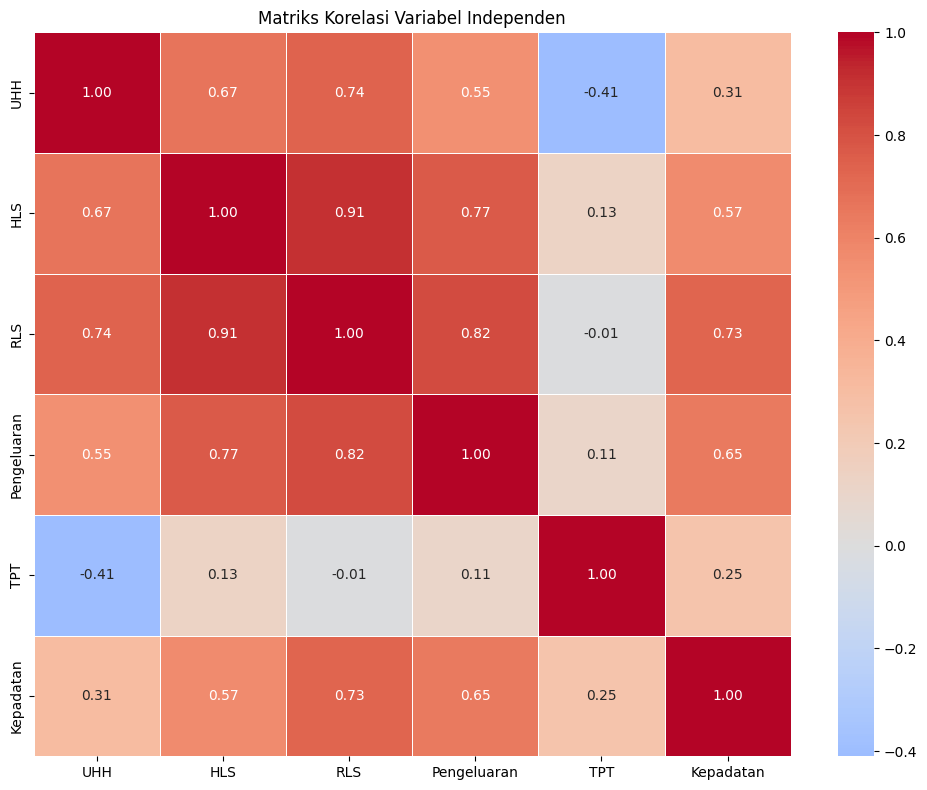


Pasangan variabel dengan korelasi tinggi (>0.7):
  UHH - RLS: 0.7362
  HLS - RLS: 0.9088
  HLS - Pengeluaran: 0.7698
  RLS - Pengeluaran: 0.8208
  RLS - Kepadatan: 0.7276


In [37]:
# ============================================================================
# UJI ASUMSI 1: MULTIKOLINEARITAS
# ============================================================================
print("\n=== UJI MULTIKOLINEARITAS (VIF) ===")
print("-" * 40)

# Hitung VIF untuk setiap variabel independen
vif_data = pd.DataFrame()
vif_data["Variabel"] = X_cols_final
vif_data["VIF"] = [variance_inflation_factor(X_train_all.values, i+1) 
                   for i in range(len(X_cols_final))]

print("Hasil Perhitungan VIF:")
print(vif_data.to_string(index=False))

print("\nInterpretasi:")
print("  - VIF < 5: tidak ada multikolinearitas serius")
print("  - VIF 5-10: multikolinearitas moderat")
print("  - VIF > 10: multikolinearitas tinggi")

# Cek korelasi antar variabel independen
print("\n=== MATRIK KORELASI VARIABEL INDEPENDEN ===")
corr_matrix = df_train[X_cols_final].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi Variabel Independen')
plt.tight_layout()
plt.show()

# Tampilkan pasangan variabel dengan korelasi tinggi
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    print("\nPasangan variabel dengan korelasi tinggi (>0.7):")
    for var1, var2, corr in high_corr_pairs:
        print(f"  {var1} - {var2}: {corr:.4f}")
else:
    print("\nTidak ada pasangan variabel dengan korelasi > 0.7")

## **Uji Asusmsi 2: Normalitas Residual**

Asumsi ini menyatakan bahwa residual (selisih antara nilai aktual dan nilai prediksi) harus berdistribusi normal.

**Hipotesis**

**H₀:** Residual berdistribusi normal.

**H₁:** Residual tidak berdistribusi normal.

#### **Metode Pengujian**

**Visualisasi:**

Q-Q Plot: Membandingkan kuantil residual dengan kuantil distribusi normal. Jika titik-titik mengikuti garis lurus, asumsi normalitas terpenuhi.
Histogram: Menunjukkan bentuk distribusi residual secara visual.

**Uji Statistik:**

Uji Shapiro-Wilk: Uji yang paling umum digunakan untuk normalitas.
Uji Anderson-Darling: Memberikan bobot lebih pada ekor distribusi.

=== UJI NORMALITAS RESIDUAL ===
----------------------------------------


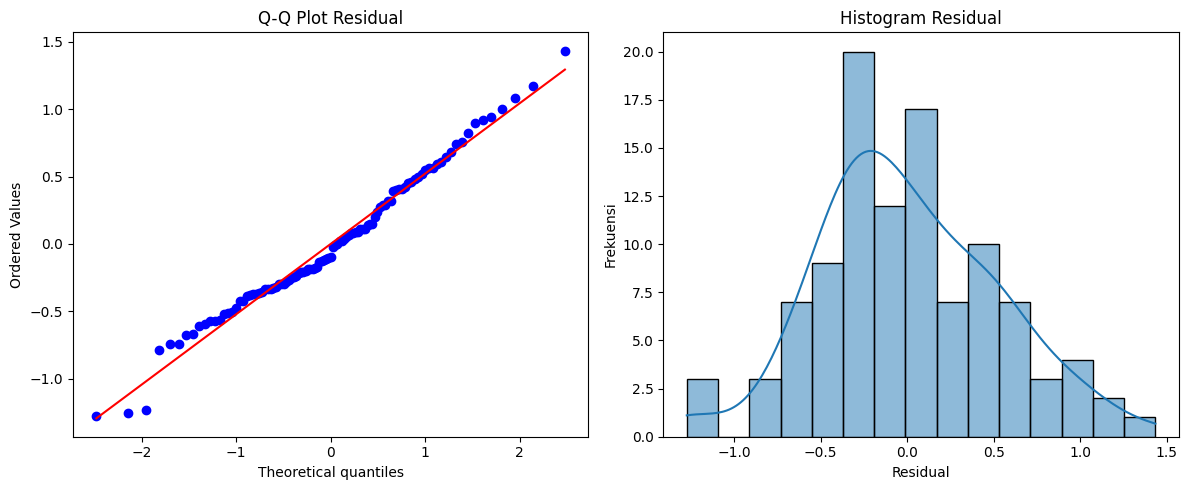

Hasil Uji Shapiro-Wilk:
  Statistik: 0.9848
  P-value: 0.2743
  Kesimpulan: Residual terdistribusi normal (gagal tolak H0)

Hasil Uji Anderson-Darling:
  Statistik: 0.6136
  P-value: 0.1078
  Kesimpulan: Residual terdistribusi normal (gagal tolak H0)


In [38]:
# ============================================================================
# UJI ASUMSI 2: NORMALITAS RESIDUAL
# ============================================================================
print("=== UJI NORMALITAS RESIDUAL ===")
print("-" * 40)

# Visualisasi
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
stats.probplot(residuals_all, plot=plt)
plt.title('Q-Q Plot Residual')

plt.subplot(1, 2, 2)
sns.histplot(residuals_all, kde=True, bins=15)
plt.title('Histogram Residual')
plt.xlabel('Residual')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

# Uji Shapiro-Wilk
shapiro_stat, shapiro_p = stats.shapiro(residuals_all)
print(f"Hasil Uji Shapiro-Wilk:")
print(f"  Statistik: {shapiro_stat:.4f}")
print(f"  P-value: {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("  Kesimpulan: Residual terdistribusi normal (gagal tolak H0)")
else:
    print("  Kesimpulan: Residual tidak terdistribusi normal (tolak H0)")

# Uji Anderson-Darling
ad_stat, ad_pvalue = normal_ad(residuals_all)
print(f"\nHasil Uji Anderson-Darling:")
print(f"  Statistik: {ad_stat:.4f}")
print(f"  P-value: {ad_pvalue:.4f}")
if ad_pvalue > 0.05:
    print("  Kesimpulan: Residual terdistribusi normal (gagal tolak H0)")
else:
    print("  Kesimpulan: Residual tidak terdistribusi normal (tolak H0)")

## **Uji Asumsi 3: Homoskedastisitas**

Asumsi ini menyatakan bahwa varians (sebaran) residual harus konstan untuk semua nilai prediksi. Jika varians tidak konstan (heteroskedastisitas), maka estimasi koefisien regresi tidak lagi efisien, dan uji signifikansi (uji t dan F) menjadi tidak dapat dipercaya.

**Hipotesis**

**H₀:** Terjadi homoskedastisitas (varians konstan).

**H₁:** Terjadi heteroskedastisitas (varians tidak konstan).

#### **Metode Pengujian**

**Visualisasi:**

Scatter Plot Residual vs. Nilai Prediksi: Plot residual terhadap nilai yang diprediksi oleh model. Jika titik-titik menyebar secara acak tanpa membentuk pola (misalnya corong), asumsi homoskedastisitas terpenuhi.

**Uji Statistik:**

Uji Breusch-Pagan: Uji formal untuk mendeteksi heteroskedastisitas.


=== UJI HOMOSKEDASTISITAS ===
----------------------------------------
Hasil Uji Breusch-Pagan:
  Statistik LM: 19.0533
  P-value LM: 0.0041
  Statistik F: 3.6209
  P-value F: 0.0028
  Kesimpulan: Heteroskedastisitas (varians tidak konstan)


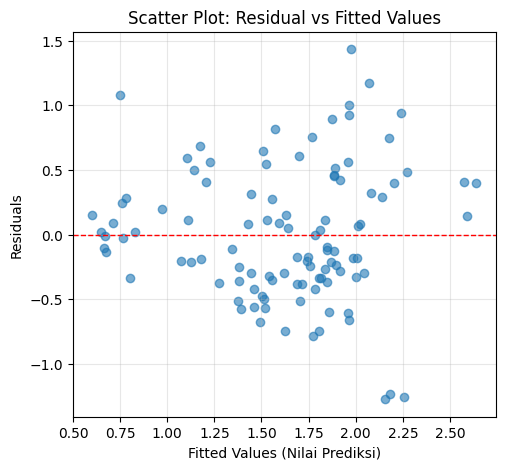

In [34]:
# ============================================================================
# UJI ASUMSI 2: HOMOSKEDASTISITAS
# ============================================================================
print("\n=== UJI HOMOSKEDASTISITAS ===")
print("-" * 40)

# Visualisasi
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(fitted_all, residuals_all, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Fitted Values (Nilai Prediksi)')
plt.ylabel('Residuals')
plt.title('Scatter Plot: Residual vs Fitted Values')
plt.grid(True, alpha=0.3)

# Uji Breusch-Pagan
bp_lm, bp_lm_pvalue, bp_fvalue, bp_f_pvalue = het_breuschpagan(residuals_all, X_train_all)
print(f"Hasil Uji Breusch-Pagan:")
print(f"  Statistik LM: {bp_lm:.4f}")
print(f"  P-value LM: {bp_lm_pvalue:.4f}")
print(f"  Statistik F: {bp_fvalue:.4f}")
print(f"  P-value F: {bp_f_pvalue:.4f}")
if bp_lm_pvalue > 0.05:
    print("  Kesimpulan: Homoskedastisitas terpenuhi (varians konstan)")
else:
    print("  Kesimpulan: Heteroskedastisitas (varians tidak konstan)")

## **Uji asumsi 4: Tidak Ada Autokorelasi**

Asumsi ini menyatakan bahwa residual (selisih antara nilai aktual dan nilai prediksi) harus berdistribusi normal. Distribusi normal yang simetris di sekitar nol menunjukkan bahwa model tidak memiliki bias sistematis dalam prediksinya.

**Hipotesis**

**H₀:** Tidak ada autokorelasi.

**H₁:** Ada autokorelasi.

#### **Metode Pengujian**

Uji Durbin-Watson: Uji statistik yang paling umum digunakan untuk mendeteksi autokorelasi orde satu.

Nilai DW mendekati 2: Tidak ada autokorelasi.

Nilai DW < 2: Ada indikasi autokorelasi positif.

Nilai DW > 2: Ada indikasi autokorelasi negatif.

In [39]:
# ============================================================================
# UJI ASUMSI 4: AUTOKORELASI
# ============================================================================
print("\n=== UJI AUTOKORELASI (Durbin-Watson) ===")
print("-" * 40)

# Hitung statistik Durbin-Watson
dw_stat = durbin_watson(residuals_all)
print(f"Statistik Durbin-Watson: {dw_stat:.4f}")
print("Interpretasi:")
print("  - Nilai 2: tidak ada autokorelasi")
print("  - Nilai 0-2: autokorelasi positif")
print("  - Nilai 2-4: autokorelasi negatif")
if 1.5 < dw_stat < 2.5:
    print(f"Kesimpulan: Tidak ada autokorelasi signifikan")
elif dw_stat <= 1.5:
    print(f"Kesimpulan: Ada autokorelasi positif")
else:
    print(f"Kesimpulan: Ada autokorelasi negatif")


=== UJI AUTOKORELASI (Durbin-Watson) ===
----------------------------------------
Statistik Durbin-Watson: 2.1025
Interpretasi:
  - Nilai 2: tidak ada autokorelasi
  - Nilai 0-2: autokorelasi positif
  - Nilai 2-4: autokorelasi negatif
Kesimpulan: Tidak ada autokorelasi signifikan


## **Uji asumsi 5: Linearitas**

Asumsi ini menyatakan bahwa hubungan antara variabel dependen (P1) dan masing-masing variabel independen adalah linear. Jika hubungannya tidak linear, model linier tidak akan mampu menangkap pola data dengan baik.

**Hipotesis**

**H₀:** Model bersifat linear.

**H₁:** Model tidak linear.

#### **Metode Pengujian**

**Visualisasi:**

Scatter Plot: Membuat plot antara P1 dan masing-masing variabel independen beserta garis regresinya.

**Uji Statistik:**

Uji Rainbow: Menguji apakah model linear lebih baik daripada model non-linear.


=== UJI LINEARITAS (Rainbow Test) ===
----------------------------------------
Statistik Rainbow: 0.9347
P-value: 0.5958
Kesimpulan: Hubungan linear terpenuhi (gagal tolak H0)

=== VISUALISASI HUBUNGAN VARIABEL DENGAN P1 ===


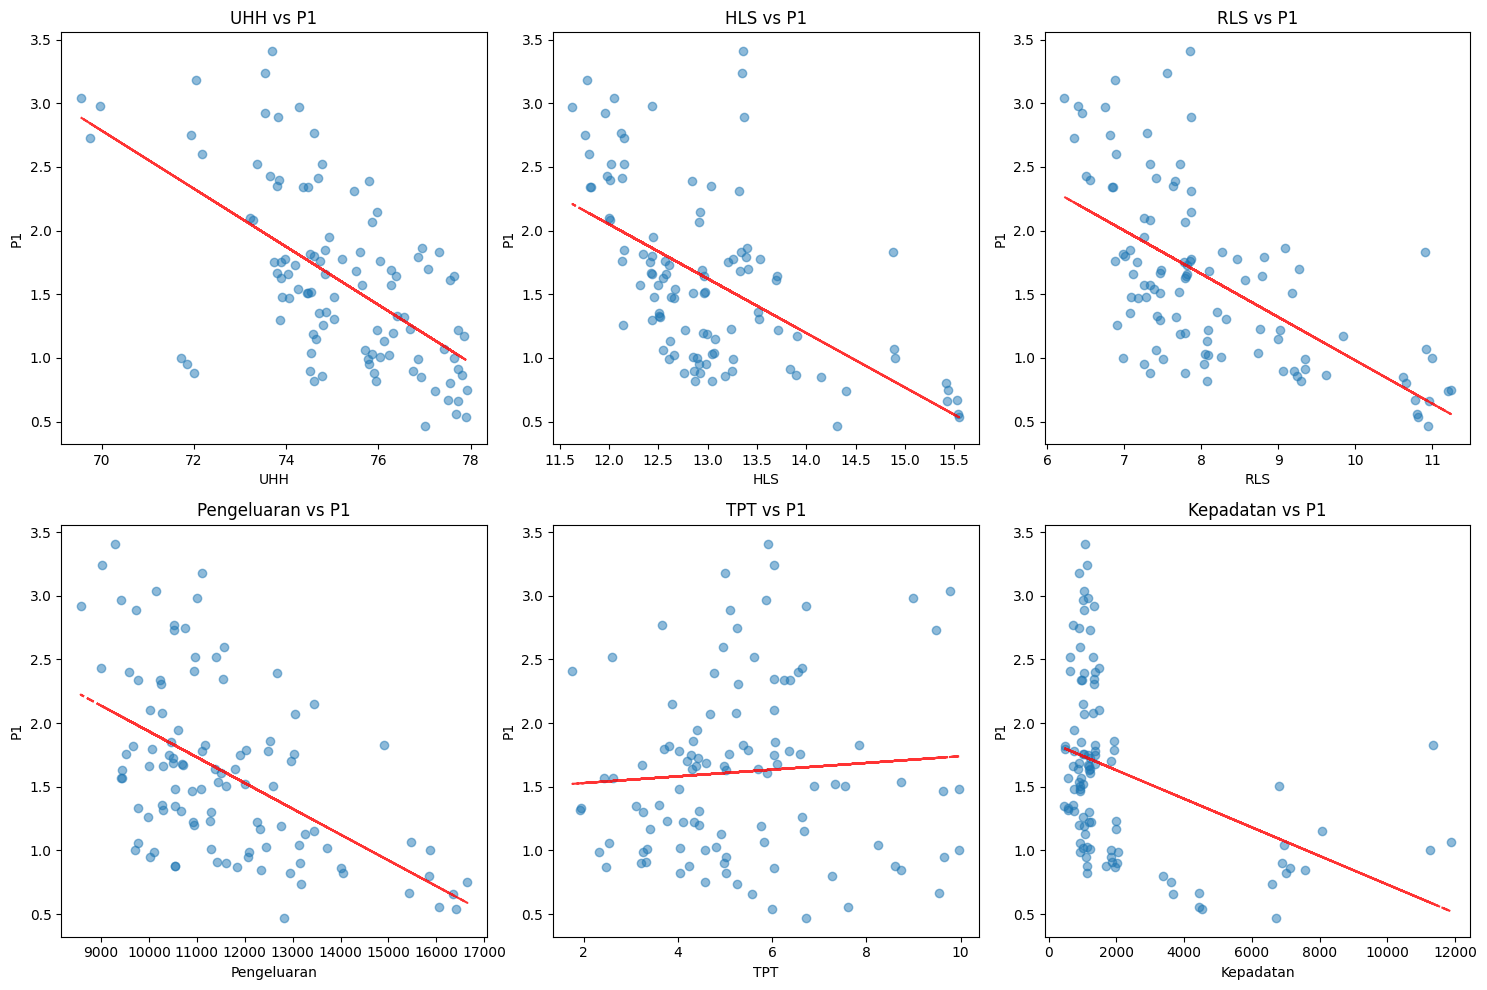

In [28]:
# ============================================================================
# UJI ASUMSI 5: LINEARITAS
# ============================================================================
print("\n=== UJI LINEARITAS (Rainbow Test) ===")
print("-" * 40)

# Uji Rainbow
rainbow_stat, rainbow_p = linear_rainbow(model_all)
print(f"Statistik Rainbow: {rainbow_stat:.4f}")
print(f"P-value: {rainbow_p:.4f}")
if rainbow_p > 0.05:
    print("Kesimpulan: Hubungan linear terpenuhi (gagal tolak H0)")
else:
    print("Kesimpulan: Hubungan tidak linear (tolak H0)")

# Visualisasi hubungan tiap variabel dengan Y
print("\n=== VISUALISASI HUBUNGAN VARIABEL DENGAN P1 ===")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(X_cols_final):
    axes[idx].scatter(df_train[col], y_train, alpha=0.5)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('P1')
    axes[idx].set_title(f'{col} vs P1')
    # Tambahkan garis regresi sederhana
    z = np.polyfit(df_train[col], y_train, 1)
    p = np.poly1d(z)
    axes[idx].plot(df_train[col], p(df_train[col]), "r--", alpha=0.8)

plt.tight_layout()
plt.show()

In [48]:
# ============================================================================
# RINGKASAN KOMPREHENSIF UJI ASUMSI
# ============================================================================
print("\n" + "="*80)
print("RINGKASAN KOMPREHENSIF UJI ASUMSI REGRESI LINEAR")
print("="*80)

summary_data = {
    'Asumsi': [
        'Normalitas Residual',
        'Homoskedastisitas',
        'Autokorelasi',
        'Multikolinearitas',
        'Linearitas'
    ],
    'Uji Statistik': [
        f'Shapiro-Wilk (p={shapiro_p:.4f})',
        f'Breusch-Pagan (p={bp_lm_pvalue:.4f})',
        f'Durbin-Watson ({dw_stat:.4f})',
        'VIF (lihat tabel)',
        f'Rainbow (p={rainbow_p:.4f})'
    ],
    'Hasil': [
        'Terpenuhi' if shapiro_p > 0.05 else 'Tidak Terpenuhi',
        'Terpenuhi' if bp_lm_pvalue > 0.05 else 'Tidak Terpenuhi',
        'Tidak ada autokorelasi' if 1.5 < dw_stat < 2.5 else 'Ada autokorelasi',
        f'{sum(vif_data["VIF"] > 10)} variabel dengan VIF > 10',
        'Terpenuhi' if rainbow_p > 0.05 else 'Tidak Terpenuhi'
    ],
    'Rekomendasi': [
        'OK' if shapiro_p > 0.05 else 'Pertimbangkan transformasi',
        'OK' if bp_lm_pvalue > 0.05 else 'Gunakan model robust',
        'OK' if 1.5 < dw_stat < 2.5 else 'Pertimbangkan time series',
        'Perlu penanganan' if any(vif_data["VIF"] > 10) else 'OK',
        'OK' if rainbow_p > 0.05 else 'Pertimbangkan model non-linear'
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "-"*80)
print("ANALISIS MULTIKOLINEARITAS DETAIL:")
print("-"*80)
for idx, row in vif_data.iterrows():
    status = "✓ Baik" if row['VIF'] < 5 else ("⚠ Sedang" if row['VIF'] < 10 else "✗ Tinggi")
    print(f"  {row['Variabel']:15} VIF = {row['VIF']:6.2f} {status}")

print("\n" + "-"*80)
print("REKOMENDASI UMUM:")
print("-"*80)

# Analisis berdasarkan hasil
issues = []

if shapiro_p <= 0.05:
    issues.append("1. Residual tidak normal - pertimbangkan transformasi Box-Cox atau menggunakan model robust")
    
if bp_lm_pvalue <= 0.05:
    issues.append("2. Heteroskedastisitas terdeteksi - gunakan White's robust standard errors")

if not (1.5 < dw_stat < 2.5):
    issues.append("3. Ada autokorelasi - pertimbangkan model dengan lag atau time series")

if any(vif_data["VIF"] > 10):
    high_vif_vars = vif_data[vif_data["VIF"] > 10]["Variabel"].tolist()
    issues.append(f"4. Multikolinearitas tinggi pada: {', '.join(high_vif_vars)} - pertimbangkan:")
    issues.append("   a. Menghapus salah satu variabel yang berkorelasi tinggi")
    issues.append("   b. Regresi ridge/lasso")
    issues.append("   c. PCA (Principal Component Analysis)")

if rainbow_p <= 0.05:
    issues.append("5. Hubungan tidak linear - pertimbangkan:")
    issues.append("   a. Transformasi variabel")
    issues.append("   b. Menambahkan interaksi atau polynomial terms")
    issues.append("   c. Model non-linear")

if outliers.size > 0:
    issues.append(f"6. Terdapat {outliers.size} observasi influential - perlu dicek validitas data")

if issues:
    print("ISSUE YANG PERLU DITANGANI:")
    for issue in issues:
        print(f"  {issue}")
else:
    print("  Semua asumsi terpenuhi dengan baik. Model dapat digunakan.")

print("\n" + "-"*80)
print("LANGKAH SELANJUTNYA UNTUK MODEL TERBAIK:")
print("-"*80)
print("1. Lakukan backward/forward selection berdasarkan signifikansi statistik")
print("2. Pertimbangkan transformasi variabel jika perlu")
print("3. Validasi model dengan data test (2024)")
print("4. Bandingkan performance metrics (R², RMSE, MAE)")
print("5. Lakukan cross-validation untuk generalisasi yang lebih baik")


RINGKASAN KOMPREHENSIF UJI ASUMSI REGRESI LINEAR
             Asumsi            Uji Statistik                      Hasil          Rekomendasi
Normalitas Residual  Shapiro-Wilk (p=0.2743)                  Terpenuhi                   OK
  Homoskedastisitas Breusch-Pagan (p=0.0041)            Tidak Terpenuhi Gunakan model robust
       Autokorelasi   Durbin-Watson (2.1025)     Tidak ada autokorelasi                   OK
  Multikolinearitas        VIF (lihat tabel) 1 variabel dengan VIF > 10     Perlu penanganan
         Linearitas       Rainbow (p=0.5958)                  Terpenuhi                   OK

--------------------------------------------------------------------------------
ANALISIS MULTIKOLINEARITAS DETAIL:
--------------------------------------------------------------------------------
  UHH             VIF =   3.88 ✓ Baik
  HLS             VIF =   8.78 ⚠ Sedang
  RLS             VIF =  17.68 ✗ Tinggi
  Pengeluaran     VIF =   3.22 ✓ Baik
  TPT             VIF =   2.07 ✓ Baik
